## Student Mental Health Survey Analysis

## 1. Domain
This project applies machine learning to understand and predict student mental wellness levels based on behavioral and psychological survey inputs.


## 2. Problem Statement


Understanding student mental health prediction and classification goals

Students often deal with stress, anxiety, irregular sleep, and lifestyle challenges that affect their mental well-being.


Goal:
* Healthy:0
*Depressed:1
Features include psychological metrics (stress, anxiety), sleep behavior, lifestyle choices, and social support indicators.
The output supports counselors and institutions in identifying at-risk students early.


## 3. Architecture / ML Workflow


## Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"/content/student_depression_dataset.csv")

In [3]:
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [4]:
df.shape

(27901, 18)

## Preprocessing


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

In [6]:
df['City'].value_counts()

,count
City,
Kalyan,1570
Srinagar,1372
Hyderabad,1340
Vasai-Virar,1290
Lucknow,1155
Thane,1139
Ludhiana,1111
Agra,1094
Surat,1078


In [7]:
df["Depression"].value_counts()

,count
Depression,
1,16336
0,11565


In [8]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,1.000000


In [11]:
df.drop(['id'], axis=1, inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 17 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 27901 non-null  object 
 1   Age                                    27901 non-null  float64
 2   City                                   27901 non-null  object 
 3   Profession                             27901 non-null  object 
 4   Academic Pressure                      27901 non-null  float64
 5   Work Pressure                          27901 non-null  float64
 6   CGPA                                   27901 non-null  float64
 7   Study Satisfaction                     27901 non-null  float64
 8   Job Satisfaction                       27901 non-null  float64
 9   Sleep Duration                         27901 non-null  object 
 10  Dietary Habits                         27901 non-null  object 
 11  De

In [13]:
df.shape

(27901, 17)

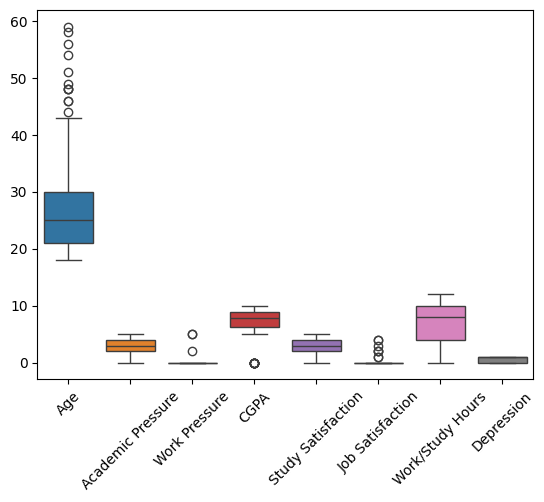

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df.select_dtypes(include=['int64','float64']))
plt.xticks(rotation=45)
plt.show()

In [15]:
cols_to_treat = ['Age', 'Work/Study Hours', 'CGPA']

for col in cols_to_treat:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

## Exploratory Data Analysis

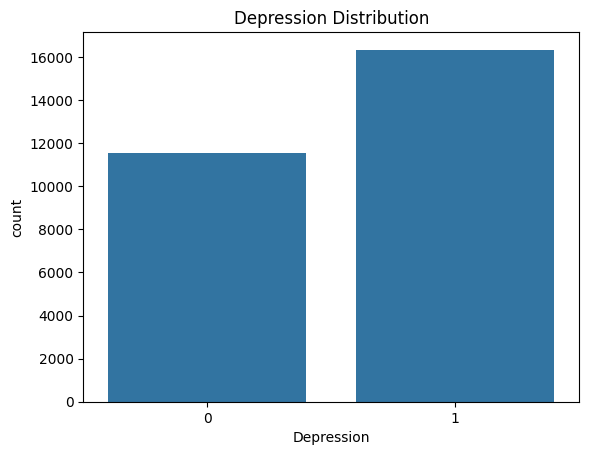

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Depression', data=df)
plt.title("Depression Distribution")
plt.show()

Check if data is balanced or imbalanced
The dataset shows slight imbalance, so I considered evaluation metrics like F1-score

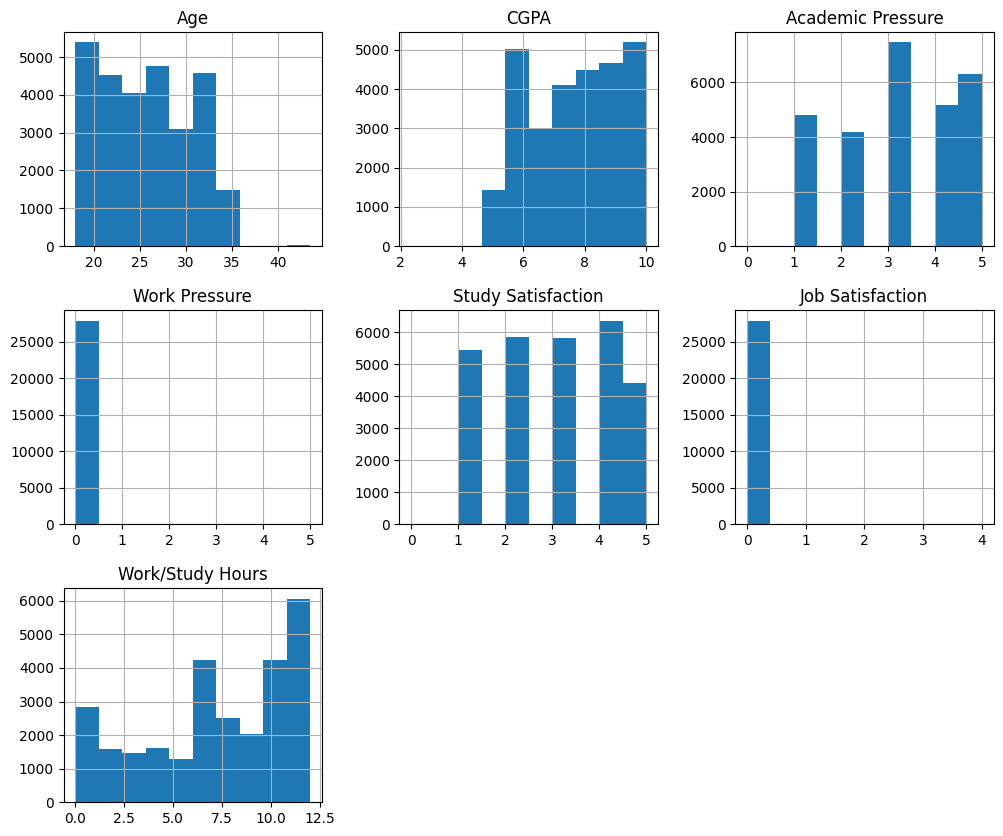

In [17]:
num_cols = ['Age','CGPA','Academic Pressure','Work Pressure',
            'Study Satisfaction','Job Satisfaction','Work/Study Hours']

df[num_cols].hist(figsize=(12,10))
plt.show()

From the distribution analysis, I observed that most students fall in the 18–30 age group with moderate to high academic pressure. Work-related features are less significant as many students are not employed. Study hours are relatively high, indicating workload intensity. Some features like job satisfaction and work pressure are highly skewed, which may reduce their importance in prediction. Overall, academic and lifestyle factors appear to play a dominant role in mental health outcomes.

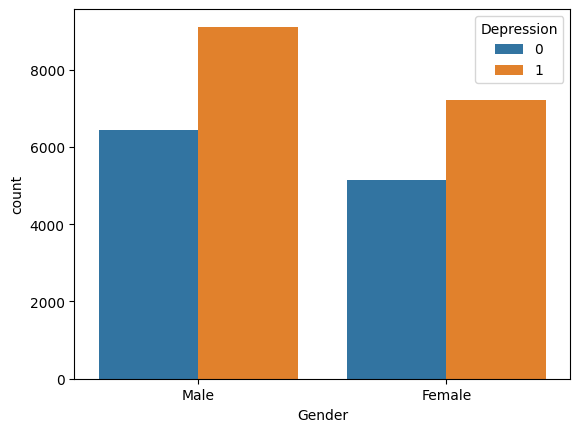

In [18]:
sns.countplot(x='Gender', hue='Depression', data=df)
plt.show()

Gender differences may exist

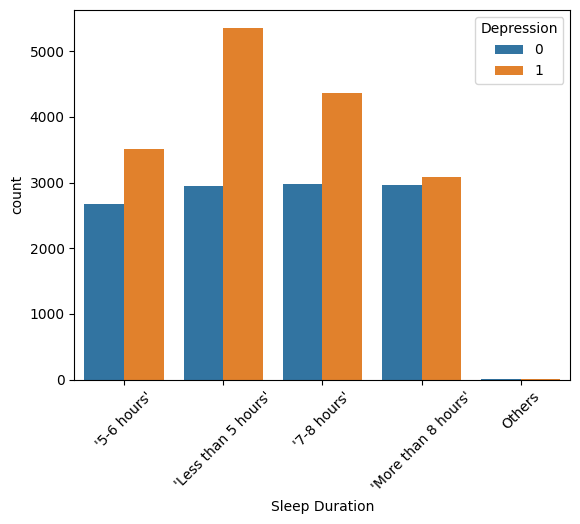

In [19]:
sns.countplot(x='Sleep Duration', hue='Depression', data=df)
plt.xticks(rotation=45)
plt.show()

Students with poor sleep show higher depression

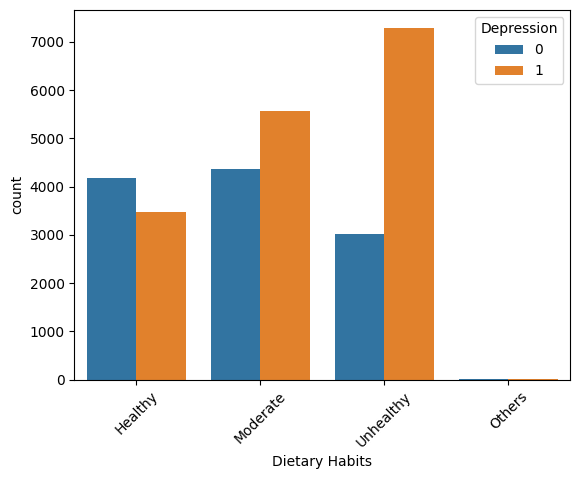

In [20]:
sns.countplot(x='Dietary Habits', hue='Depression', data=df)
plt.xticks(rotation=45)
plt.show()

Unhealthy diet correlates with mental stress

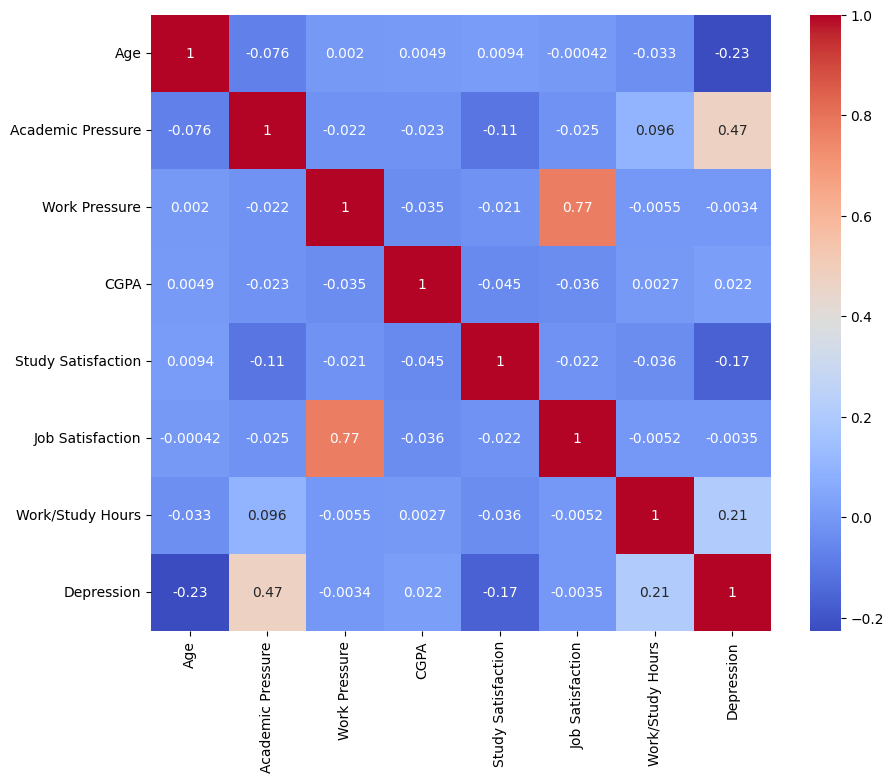

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Academic Pressure ↔ Depression

Study Satisfaction ↔ Depression (negative correlation)

Work Hours ↔ Stress

“Correlation analysis shows that pressure-related features positively correlate with depression, while satisfaction features show negative correlation.”

# Train Test splitting

In [22]:
X = df.drop('Depression', axis=1)
y = df['Depression']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


## Feature scaling

In [23]:
categorical_cols = [
    'Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits',
    'Degree', 'Have you ever had suicidal thoughts ?',
    'Financial Stress', 'Family History of Mental Illness'
]

numerical_cols = [
    'Age', 'Academic Pressure', 'Work Pressure', 'CGPA',
    'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours'
]

In [24]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# IMPORTANT FIX
feature_names = preprocessor.get_feature_names_out()

import pandas as pd
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df = pd.DataFrame(X_test_processed, columns=feature_names)

In [25]:
X_train_df.head()

,num__Age,num__Academic Pressure,num__Work Pressure,num__CGPA,num__Study Satisfaction,num__Job Satisfaction,num__Work/Study Hours,cat__Gender,cat__City,cat__Profession,cat__Sleep Duration,cat__Dietary Habits,cat__Degree,cat__Have you ever had suicidal thoughts ?,cat__Financial Stress,cat__Family History of Mental Illness
0,-0.363296,1.342383,-0.008701,0.716794,-1.424923,-0.013776,-0.857348,1.0,15.0,9.0,3.0,3.0,1.0,0.0,2.0,1.0
1,-0.363296,-0.104078,-0.008701,0.259883,0.779880,-0.013776,-1.938523,1.0,19.0,9.0,2.0,0.0,1.0,0.0,1.0,0.0
2,0.249226,-1.550539,-0.008701,0.321259,-1.424923,-0.013776,-0.046466,0.0,44.0,9.0,3.0,0.0,12.0,1.0,1.0,0.0
3,1.678442,1.342383,-0.008701,1.344194,-1.424923,-0.013776,0.494122,1.0,17.0,9.0,3.0,0.0,15.0,0.0,4.0,1.0
4,0.861747,1.342383,-0.008701,-0.374336,0.779880,-0.013776,0.223828,0.0,42.0,9.0,0.0,3.0,0.0,1.0,2.0,1.0


In [26]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_df, y_train)

In [27]:
X_train_smote.head()

,num__Age,num__Academic Pressure,num__Work Pressure,num__CGPA,num__Study Satisfaction,num__Job Satisfaction,num__Work/Study Hours,cat__Gender,cat__City,cat__Profession,cat__Sleep Duration,cat__Dietary Habits,cat__Degree,cat__Have you ever had suicidal thoughts ?,cat__Financial Stress,cat__Family History of Mental Illness
0,-0.363296,1.342383,-0.008701,0.716794,-1.424923,-0.013776,-0.857348,1.0,15.0,9.0,3.0,3.0,1.0,0.0,2.0,1.0
1,-0.363296,-0.104078,-0.008701,0.259883,0.779880,-0.013776,-1.938523,1.0,19.0,9.0,2.0,0.0,1.0,0.0,1.0,0.0
2,0.249226,-1.550539,-0.008701,0.321259,-1.424923,-0.013776,-0.046466,0.0,44.0,9.0,3.0,0.0,12.0,1.0,1.0,0.0
3,1.678442,1.342383,-0.008701,1.344194,-1.424923,-0.013776,0.494122,1.0,17.0,9.0,3.0,0.0,15.0,0.0,4.0,1.0
4,0.861747,1.342383,-0.008701,-0.374336,0.779880,-0.013776,0.223828,0.0,42.0,9.0,0.0,3.0,0.0,1.0,2.0,1.0


## Feature Selection

In [28]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_train_smote, y_train_smote)

mi_df = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Score': mi_scores
}).sort_values(by='Score', ascending=False)

print(mi_df.head(15))

                                       Feature     Score
13  cat__Have you ever had suicidal thoughts ?  0.199620
1                       num__Academic Pressure  0.187863
14                       cat__Financial Stress  0.127390
0                                     num__Age  0.119862
6                        num__Work/Study Hours  0.111107
3                                    num__CGPA  0.092813
4                      num__Study Satisfaction  0.084162
10                         cat__Sleep Duration  0.061623
12                                 cat__Degree  0.058711
8                                    cat__City  0.052272
11                         cat__Dietary Habits  0.051784
15       cat__Family History of Mental Illness  0.046392
7                                  cat__Gender  0.038076
9                              cat__Profession  0.005497
5                        num__Job Satisfaction  0.000000


Psychological indicators like suicidal thoughts dominate the prediction, followed by academic pressure and financial stress. Lifestyle factors such as sleep and diet also contribute, but with relatively lower importance

In [29]:
top_features = mi_df.head(15)['Feature'].tolist()

X_train_selected = X_train_smote[top_features]
X_test_selected = X_test_df[top_features]

In [30]:
X_train_selected.shape

(26156, 15)

In [31]:
X_test_selected.shape

(5581, 15)

In [32]:
y_train_smote.shape

(26156,)

# LogisticRegression

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_selected, y_train_smote)

y_pred_lr = lr_model.predict(X_test_selected)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8396344741085827
              precision    recall  f1-score   support

           0       0.79      0.83      0.81      2323
           1       0.88      0.85      0.86      3258

    accuracy                           0.84      5581
   macro avg       0.83      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



# DecisionTreeClassifier


In [34]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_selected, y_train_smote)

y_pred_dt = dt_model.predict(X_test_selected)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.766350116466583
              precision    recall  f1-score   support

           0       0.72      0.73      0.72      2323
           1       0.80      0.79      0.80      3258

    accuracy                           0.77      5581
   macro avg       0.76      0.76      0.76      5581
weighted avg       0.77      0.77      0.77      5581



# RandomForestClassifier

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_selected, y_train_smote)

y_pred_rf = rf_model.predict(X_test_selected)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8401720121841963
              precision    recall  f1-score   support

           0       0.82      0.79      0.81      2323
           1       0.86      0.87      0.86      3258

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581



# KNN

In [36]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()
knn_model.fit(X_train_selected, y_train_smote)

y_pred_knn = knn_model.predict(X_test_selected)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.761333094427522
              precision    recall  f1-score   support

           0       0.70      0.74      0.72      2323
           1       0.81      0.77      0.79      3258

    accuracy                           0.76      5581
   macro avg       0.75      0.76      0.76      5581
weighted avg       0.76      0.76      0.76      5581



# SVM

In [37]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train_selected, y_train_smote)

y_pred_svm = svm_model.predict(X_test_selected)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8426805232037269
              precision    recall  f1-score   support

           0       0.80      0.83      0.82      2323
           1       0.88      0.85      0.86      3258

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



# GradientBoostingClassifier

In [38]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train_selected, y_train_smote)

y_pred_gb = gb_model.predict(X_test_selected)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8441139580720302
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2323
           1       0.86      0.87      0.87      3258

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



# XGBoost

In [39]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_selected, y_train_smote)

y_pred_xgb = xgb_model.predict(X_test_selected)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:38:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.83390073463537
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      2323
           1       0.85      0.86      0.86      3258

    accuracy                           0.83      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.83      0.83      0.83      5581



# AdaBoost

In [40]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(random_state=42)
ada_model.fit(X_train_selected, y_train_smote)

y_pred_ada = ada_model.predict(X_test_selected)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.8405303709012721
              precision    recall  f1-score   support

           0       0.81      0.81      0.81      2323
           1       0.86      0.86      0.86      3258

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



# Naive Bayes

In [41]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_selected, y_train_smote)

y_pred_nb = nb_model.predict(X_test_selected)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.77853431284716
              precision    recall  f1-score   support

           0       0.67      0.93      0.78      2323
           1       0.93      0.67      0.78      3258

    accuracy                           0.78      5581
   macro avg       0.80      0.80      0.78      5581
weighted avg       0.82      0.78      0.78      5581



## Model Building (Baseline Model):RandomForest Classifier

In [42]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train_df, y_train)

y_pred = model.predict(X_test_df)

In [43]:
test_accuracy=accuracy_score(y_test, y_pred)
print(test_accuracy)

0.8416054470524995


In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.79      0.81      2323
           1       0.86      0.88      0.87      3258

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.84      5581
weighted avg       0.84      0.84      0.84      5581



In [45]:
from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train_df)
train_acc = accuracy_score(y_train, y_train_pred)

print("Train Accuracy:", train_acc)

Train Accuracy: 0.9999551971326165


## Advanced Model Development:Xgboost Classifier

In [46]:
from xgboost import XGBClassifier

In [47]:
best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.05,
    'max_depth': 4,
    'n_estimators': 200,
    'reg_alpha': 0.01,
    'reg_lambda': 1.5,
    'subsample': 1
}

# Create the model using these parameters
from xgboost import XGBClassifier

model = XGBClassifier(
    **best_params,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train_selected, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [48]:
y_preds = model.predict(X_test_selected)

In [49]:
accuracy = accuracy_score(y_test, y_preds)
print("Accuracy:", accuracy)

Accuracy: 0.8433972406378785


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2323
           1       0.86      0.87      0.87      3258

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



In [51]:
y_train_preds = model.predict(X_train_selected)
train_acc = accuracy_score(y_train_smote, y_train_preds)

print("Train Accuracy:", train_acc)

Train Accuracy: 0.8759749197124943


## without feature selection building model

## Randomforest

In [52]:
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train_df, y_train)
y_pred = model.predict(X_test_df)

In [53]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8408887296183479


In [54]:
y_train_pred = model.predict(X_train_df)

In [55]:
accuracy = accuracy_score(y_train, y_train_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8894713261648746


## XG boost

In [56]:
from xgboost import XGBClassifier

In [57]:
best_params = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.05,
    'max_depth': 4,
    'n_estimators': 200,
    'reg_alpha': 0.01,
    'reg_lambda': 1.5,
    'subsample': 1
}

# Create the model using these parameters
from xgboost import XGBClassifier

model = XGBClassifier(
    **best_params,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train_df, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [58]:
y_train_pred = model.predict(X_train_df)
train_acc = accuracy_score(y_train, y_train_pred)
print("Training Accuracy:", train_acc)

Training Accuracy: 0.8584677419354839


In [59]:
y_test_pred = model.predict(X_test_df)
test_acc = accuracy_score(y_test, y_test_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.8441139580720302


In [60]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2323
           1       0.86      0.88      0.87      3258

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



## Hyperparameter Tuning

## Randomforest Classifier

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_selected, y_train_smote)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best RF Params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best RF Score: 0.860453727396718


In [62]:
best_model = grid_rf.best_estimator_

# Predict
y_pred = best_model.predict(X_test_selected)

In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81      2323
           1       0.86      0.87      0.87      3258

    accuracy                           0.84      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.84      0.84      0.84      5581



In [64]:
y_train_pred = best_model.predict(X_train_selected)
train_acc = accuracy_score(y_train_smote, y_train_pred)
print("Training Accuracy:", train_acc)

Training Accuracy: 0.8944410460315033


In [65]:
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.8423221644866511


## XGBClassifier

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_selected, y_train_smote)

print("Best XGB Params:", grid_xgb.best_params_)
print("Best XGB Score:", grid_xgb.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


In [ ]:
best_xgb = grid_xgb.best_estimator_

y_preds = best_xgb.predict(X_test_selected)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds))

In [ ]:
test_acc = accuracy_score(y_test, y_preds)
print("Test Accuracy:", test_acc)

In [ ]:
y_train_preds = best_xgb.predict(X_train_selected)
train_acc = accuracy_score(y_train_smote, y_train_preds)
print("Training Accuracy:", train_acc)

In [ ]:
import pickle

# Save preprocessor
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

# Save top features (make sure it's a list)
with open("top_features.pkl", "wb") as f:
    pickle.dump(list(top_features), f)

# Save trained model
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save feature names (VERY IMPORTANT)
with open("feature_names.pkl", "wb") as f:
    pickle.dump(list(feature_names), f)

print("Files saved:",
      "preprocessor.pkl, top_features.pkl, xgb_model.pkl, feature_names.pkl")

In [ ]:
import xgboost as xgb
print(xgb.__version__)